## UNIL Field Camp Data Processing

In [1]:
# imports
import pyrsktools as rsk
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fpath = '205750_20260604_1458.rsk'

In [24]:
with rsk.RSK(fpath) as f:
    f.readdata(t1=pd.to_datetime('2000-08-06'))
    data = f.data

    f.computeprofiles()
    downcast = f.getprofilesindices(direction='down')

data = pd.DataFrame(data)
data = data.set_index('timestamp')
ds = xr.Dataset.from_dataframe(data)
#ds = ds.sel(timestamp=slice('2026-06-04 09:30:00', '2026-06-04 10:30:00'))

Ruskin profile and cast annotations will be deleted as they might conflict with the new profiles detected


In [ ]:
t_sensor = pd.to_datetime('2000-08-06T16:37:45.000')
t_watch = pd.to_datetime('2026-06-04 09:13:00')
t_offset = t_watch - t_sensor

In [31]:
with rsk.RSK(fpath) as f:
    f.readdata(t1=pd.to_datetime('2000-08-06'))    # time offset
    df = pd.DataFrame(f.data["timestamp"], columns=["time"])

In [34]:
df

,time
0,2000-08-06 16:37:45.000
1,2000-08-06 16:37:45.250
2,2000-08-06 16:37:45.500
3,2000-08-06 16:37:45.750
4,2000-08-06 17:31:48.000
...,...
6430,2000-08-06 20:49:04.250
6431,2000-08-06 21:32:09.000
6432,2000-08-06 21:34:13.000
6433,2000-08-06 22:36:49.000


In [36]:
df['time'] + t_offset

0      2026-06-04 09:13:00.000
1      2026-06-04 09:13:00.250
2      2026-06-04 09:13:00.500
3      2026-06-04 09:13:00.750
4      2026-06-04 10:07:03.000
                 ...          
6430   2026-06-04 13:24:19.250
6431   2026-06-04 14:07:24.000
6432   2026-06-04 14:09:28.000
6433   2026-06-04 15:12:04.000
6434   2026-06-04 15:31:49.000
Name: time, Length: 6435, dtype: datetime64[ns]

In [30]:
t_offset

Timedelta('9432 days 16:35:15')

In [27]:
ds.timestamp

<xarray.DataArray 'timestamp' (timestamp: 6435)> Size: 51kB
array(['2000-08-06T16:37:45.000', '2000-08-06T16:37:45.250',
       '2000-08-06T16:37:45.500', ..., '2000-08-06T21:34:13.000',
       '2000-08-06T22:36:49.000', '2000-08-06T22:56:34.000'],
      shape=(6435,), dtype='datetime64[ms]')
Coordinates:
  * timestamp  (timestamp) datetime64[ms] 51kB 2000-08-06T16:37:45 ... 2000-0...

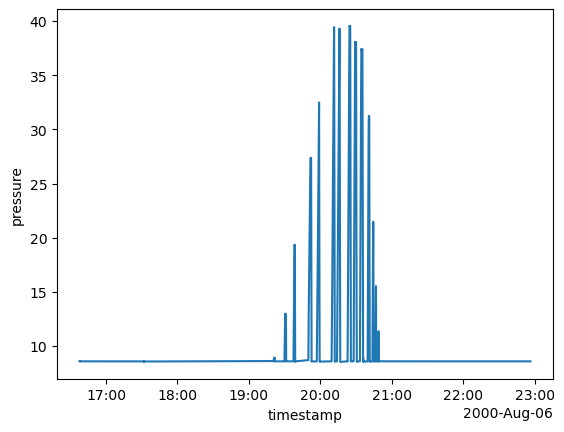

In [26]:
ds.pressure.plot()

In [6]:
len(downcast)

32

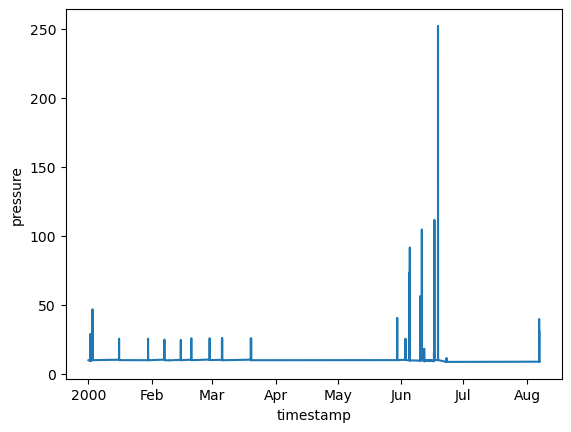

In [7]:
ds.pressure.plot()

In [20]:
ds = ds.sel(timestamp=slice('2000-08-06 19:00:00', '2000-08-06 21:00:00'))

In [22]:
ds['press'] = ds['pressure'] - ds['pressure'].min().item()

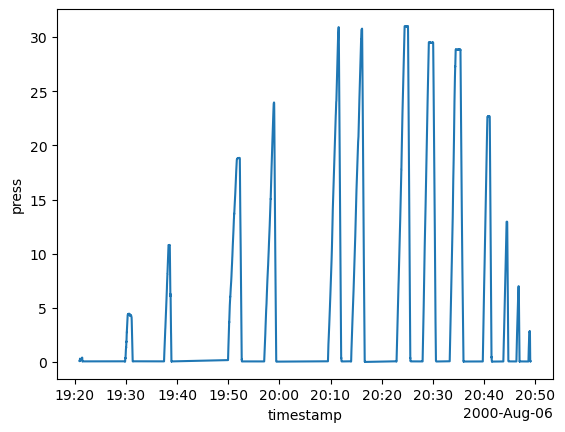

In [23]:
ds.press.plot()

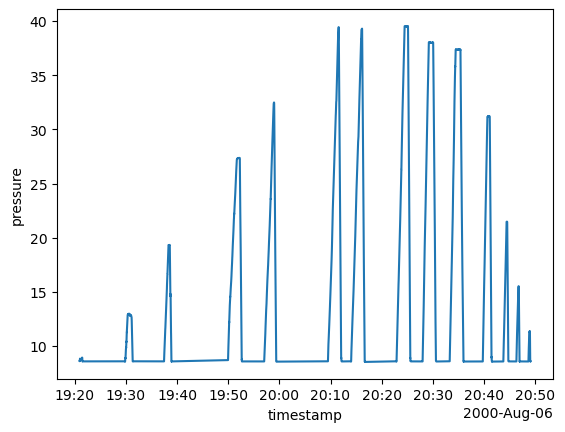

In [19]:
ds.sel(timestamp=slice('2000-08-06 19:00:00', '2000-08-06 21:00:00')).pressure.plot()

In [17]:
ds.sel(timestamp=slice('2000-08-01 19:00:00', None)).timestamp

<xarray.DataArray 'timestamp' (timestamp: 6435)> Size: 51kB
array(['2000-08-06T16:37:45.000', '2000-08-06T16:37:45.250',
       '2000-08-06T16:37:45.500', ..., '2000-08-06T21:34:13.000',
       '2000-08-06T22:36:49.000', '2000-08-06T22:56:34.000'],
      shape=(6435,), dtype='datetime64[ms]')
Coordinates:
  * timestamp  (timestamp) datetime64[ms] 51kB 2000-08-06T16:37:45 ... 2000-0...